
# Dynamic Neighborhood Simulations

This notebook runs the **evolving-neighborhood** VEGF–GLUT1 model and generates the cleaned simulation panels used in this project.

## What this notebook does
- imports the evolving-neighborhood model from either a `utils/`
- defines a single editable parameter block for the simulations
- runs **ESS** simulations across multiple values of the resource-sharing parameter `q`
- runs the corresponding **Team Optimum** simulation
- exports the simulated trajectories to Excel workbooks
- generates the main evolving-neighborhood panels in a reproducible order

## Panels included
1. **ESS varying-`q` panel**  
   A `1 × 3` panel showing `N(t)`, `u(t)`, and `y(t)` with curves varying across `q`.
2. **Team Optimum panel**  
   A `1 × 3` panel showing `N(t)`, `u(t)`, and `y(t)`.
3. **ESS panel C**  
   A `2 × 3` panel with columns corresponding to low, intermediate, and high resource sharing (`q = 0.1, 0.5, 0.9`).

## Notes
- This notebook is designed to run **top to bottom** without repeated imports or repeated helper-function definitions.
- All outputs are written under `outputs/evolving_neighborhoods/`.


In [1]:

# ------------------------------ Setup ---------------------------------
from pathlib import Path
import sys
from typing import Dict, Any, List

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib import cm, colors

# Try to locate the project root so imports work in both:
# 1) a cleaned repo layout with utils/
# 2) a flat layout where the .py files sit next to the notebook
CANDIDATE_ROOTS = [
    Path.cwd(),
    Path.cwd().parent,
    Path("/mnt/data"),
]

PROJECT_ROOT = None
for root in CANDIDATE_ROOTS:
    if (root / "utils").exists() or (root / "evolving_neighborhood.py").exists():
        PROJECT_ROOT = root
        break

if PROJECT_ROOT is None:
    PROJECT_ROOT = Path.cwd()

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

USE_UTILS_PACKAGE = (PROJECT_ROOT / "utils").exists()

if USE_UTILS_PACKAGE:
    from utils.evolving_neighborhood import integrate_ess, integrate_teamopt
    from utils.model_params import evolving_defaults, apply_overrides, to_dict
    print("Imported modules from utils/")
else:
    from evolving_neighborhood import integrate_ess, integrate_teamopt
    from model_params import evolving_defaults, apply_overrides, to_dict
    print("Imported modules from the flat project layout")

print(f"Using project root: {PROJECT_ROOT}")
print("Imports loaded successfully.")


Imported modules from utils/
Using project root: C:\Users\80019048\Projects\vegf-glut1-coadaptation
Imports loaded successfully.



## Plot styling, output folders, and parameter defaults

This section defines the figure styling, output locations, and the baseline parameter set used for the evolving-neighborhood simulations.

The ESS simulations vary the sharing parameter `q` across:
`0.1, 0.3, 0.5, 0.7, 0.9`

The initial condition is:
- `N0 = 5.0`
- `u0 = 0.5`
- `y0 = 0.5`


In [2]:

# -------------------------- Plot style & defaults --------------------------
mpl.rcParams["svg.fonttype"] = "none"
mpl.rcParams["font.sans-serif"] = ["Arial", "DejaVu Sans"]
mpl.rcParams["savefig.transparent"] = False
mpl.rcParams["path.simplify"] = True

plt.rcParams.update({
    "axes.titlesize": 18,
    "axes.labelsize": 16,
    "xtick.labelsize": 15,
    "ytick.labelsize": 15,
    "legend.fontsize": 13,
    "lines.linewidth": 4.5,
})

# Output folders
ESS_OUT = PROJECT_ROOT / "outputs" / "evolving_neighborhoods" / "ESS_dynamics" / "short_time"
TO_OUT  = PROJECT_ROOT / "outputs" / "evolving_neighborhoods" / "team_opt_dynamics" / "short_time"
ESS_OUT.mkdir(parents=True, exist_ok=True)
TO_OUT.mkdir(parents=True, exist_ok=True)

# Base parameters for ESS
p_ESS = evolving_defaults(
    sigma_u=0.8,
    sigma_y=0.8,
    t_max=500000.0,
)

# Resource-sharing values to simulate
q_values = [0.1, 0.3, 0.5, 0.7, 0.9]

# Initial conditions
N0, u0, y0 = 5.0, 0.5, 0.5

# Team Optimum differs only in the simulation horizon here
p_TO = apply_overrides(p_ESS, t_max=100000.0)

print("ESS output directory:", ESS_OUT)
print("TO output directory:", TO_OUT)
print("ESS parameters:", p_ESS)
print("TO parameters:", p_TO)


ESS output directory: C:\Users\80019048\Projects\vegf-glut1-coadaptation\outputs\evolving_neighborhoods\ESS_dynamics\short_time
TO output directory: C:\Users\80019048\Projects\vegf-glut1-coadaptation\outputs\evolving_neighborhoods\team_opt_dynamics\short_time
ESS parameters: EvolvingParams(b=1.0, R=100.0, a=0.05, k=0.05, c=0.01, h=0.01, f=0.005, sigma_u=0.8, sigma_y=0.8, t_max=500000.0, atol=1e-09, rtol=1e-07, max_step=50.0, e=1.0, d=1.0, m_G=0.0, m_A=0.0, t_drug=inf, N_floor=1.0, u_eps=1e-08)
TO parameters: EvolvingParams(b=1.0, R=100.0, a=0.05, k=0.05, c=0.01, h=0.01, f=0.005, sigma_u=0.8, sigma_y=0.8, t_max=100000.0, atol=1e-09, rtol=1e-07, max_step=50.0, e=1.0, d=1.0, m_G=0.0, m_A=0.0, t_drug=inf, N_floor=1.0, u_eps=1e-08)



## Shared helpers

These helper functions are used throughout the notebook for:
- color assignment
- Excel export
- convenient retrieval of runs by `q`


In [3]:

# ------------------------------ Helpers --------------------------------
def truncated_cmap(name: str, low: float = 0.35, high: float = 0.98, n: int = 256):
    """Return a truncated colormap to avoid overly pale tones."""
    base = cm.get_cmap(name)
    return colors.LinearSegmentedColormap.from_list(
        f"trunc_{name}_{low}_{high}",
        base(np.linspace(low, high, n))
    )


def ordinal_colors(values, cmap, low=0.35, high=0.98):
    """Assign ordered values to evenly spaced colors within a colormap range."""
    vals = sorted(values)
    t = np.linspace(low, high, len(vals))
    return {v: cmap(x) for v, x in zip(vals, t)}


# Canonical overlay colors used in Panel C
N_COLOR = "#2E8B57"   # green
U_COLOR = "#0000FF"   # blue
Y_COLOR = "#FF00FF"   # magenta

# Variable-specific palettes for the ESS varying-q panel
CMAP_N = truncated_cmap("Greens", 0.25, 0.95)
CMAP_U = truncated_cmap("Blues",  0.25, 0.95)
CMAP_Y = truncated_cmap("RdPu",   0.25, 0.95)

Q_COLOR_N = ordinal_colors(q_values, CMAP_N, low=0.25, high=0.95)
Q_COLOR_U = ordinal_colors(q_values, CMAP_U, low=0.25, high=0.95)
Q_COLOR_Y = ordinal_colors(q_values, CMAP_Y, low=0.25, high=0.95)

# Single-q color for Team Optimum
Q_COLOR_TO = "#7A0177"


def write_panel_workbook(xlsx_path: Path,
                         params_dict: Dict[str, Any],
                         runs: List[Dict[str, Any]]) -> None:
    """Write a panel workbook with one params sheet and one sheet per trajectory."""
    xlsx_path.parent.mkdir(parents=True, exist_ok=True)

    with pd.ExcelWriter(xlsx_path, engine="xlsxwriter") as writer:
        metadata = pd.DataFrame({
            "parameter": list(params_dict.keys()),
            "value": [str(v) for v in params_dict.values()],
        })
        metadata.to_excel(writer, sheet_name="params", index=False)

        for run in runs:
            df = pd.DataFrame({
                "t": run["t"],
                "N": run["N"],
                "u": run["u"],
                "y": run["y"],
            })
            sheet_name = run["sheet"]
            if len(sheet_name) > 31:
                sheet_name = (
                    sheet_name.replace(" ", "")
                              .replace("|", "_")
                              .replace("=", "")
                              .replace(".", "p")
                )[:31]
            df.to_excel(writer, sheet_name=sheet_name, index=False)


def runs_by_q(runs: List[Dict[str, Any]]) -> Dict[float, Dict[str, Any]]:
    """Return a dictionary keyed by q extracted from sheet labels like 'q=0.5'."""
    out = {}
    for run in runs:
        q = float(run["sheet"].split("=")[1])
        out[q] = run
    return out



## ESS simulations and varying-`q` panel

The next cell runs the ESS trajectories across all five resource-sharing values and creates the `1 × 3` figure:

- `N(t)` in green shades
- `u(t)` in blue shades
- `y(t)` in pink/purple shades

Within each axis, darker shades correspond to larger `q`.


Saved ESS figure: C:\Users\80019048\Projects\vegf-glut1-coadaptation\outputs\evolving_neighborhoods\ESS_dynamics\short_time\Evolving_Neighborhood_ESS_Varying_q.png
Saved ESS workbook: C:\Users\80019048\Projects\vegf-glut1-coadaptation\outputs\evolving_neighborhoods\ESS_dynamics\short_time\Evolving_Neighborhood_Varying_ESS_q_data.xlsx


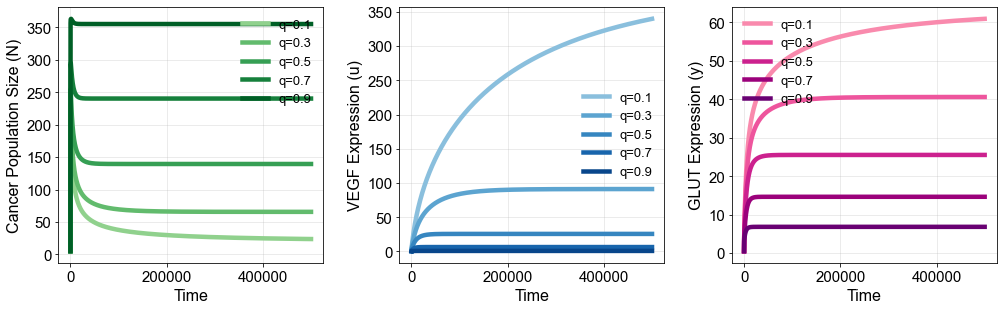

In [4]:

# ---------------- ESS simulations + varying-q panel ----------------
fig_ESS, axes_ESS = plt.subplots(1, 3, figsize=(14, 4.2), constrained_layout=True, sharey=False)
axN, axU, axY = axes_ESS

runs_ESS = []
for q in q_values:
    res = integrate_ess(q=q, p=p_ESS, N0=N0, u0=u0, y0=y0)
    t, N, u, y = res["t"], res["N"], res["u"], res["y"]

    axN.plot(t, N, color=Q_COLOR_N[q], lw=4.5, label=f"q={q}")
    axU.plot(t, u, color=Q_COLOR_U[q], lw=4.5, label=f"q={q}")
    axY.plot(t, y, color=Q_COLOR_Y[q], lw=4.5, label=f"q={q}")

    runs_ESS.append({
        "sheet": f"q={q:.1f}",
        "t": t,
        "N": N,
        "u": u,
        "y": y,
    })

# Axis labels
axN.set_xlabel("Time")
axU.set_xlabel("Time")
axY.set_xlabel("Time")

axN.set_ylabel("Cancer Population Size (N)")
axU.set_ylabel("VEGF Expression (u)")
axY.set_ylabel("GLUT Expression (y)")

for ax in axes_ESS:
    ax.legend(frameon=False, loc="best")
    ax.grid(True, alpha=0.3)

# Save figure
fig_ESS_png = ESS_OUT / "Evolving_Neighborhood_ESS_Varying_q.png"
fig_ESS_svg = ESS_OUT / "Evolving_Neighborhood_ESS_Varying_q.svg"
fig_ESS.savefig(fig_ESS_png, dpi=300, bbox_inches="tight")
fig_ESS.savefig(fig_ESS_svg, format="svg", bbox_inches="tight", metadata={"Date": None})

# Save workbook
params_ESS = to_dict(p_ESS)
params_ESS.update({
    "panel": "EV-ESS-B",
    "varied_parameter": "q",
    "q_values": q_values,
    "N0": N0,
    "u0": u0,
    "y0": y0,
})
ess_workbook = ESS_OUT / "Evolving_Neighborhood_Varying_ESS_q_data.xlsx"
write_panel_workbook(ess_workbook, params_ESS, runs_ESS)

print("Saved ESS figure:", fig_ESS_png)
print("Saved ESS workbook:", ess_workbook)
plt.show()


Saved ESS TOTAL figure: C:\Users\80019048\Projects\vegf-glut1-coadaptation\outputs\evolving_neighborhoods\ESS_dynamics\short_time\Evolving_Neighborhood_ESS_Varying_q_TOTAL.png
Saved ESS TOTAL workbook: C:\Users\80019048\Projects\vegf-glut1-coadaptation\outputs\evolving_neighborhoods\ESS_dynamics\short_time\Evolving_Neighborhood_Varying_ESS_q_TOTAL_data.xlsx


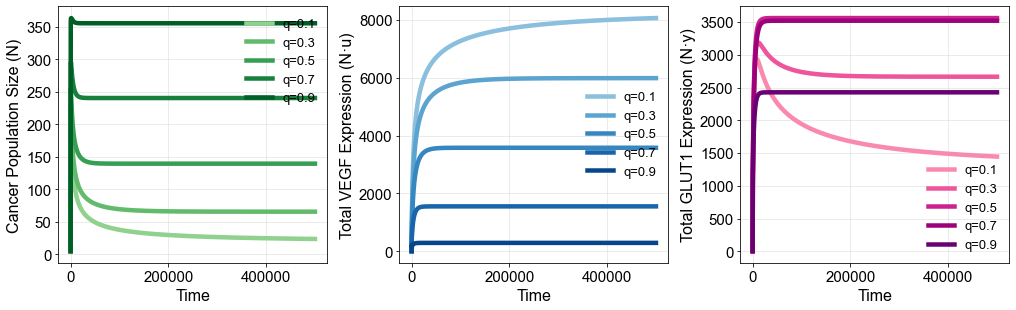

In [5]:
# ---------------- ESS simulations + varying-q panel (TOTAL expression) ----------------
fig_ESS, axes_ESS = plt.subplots(1, 3, figsize=(14, 4.2), constrained_layout=True, sharey=False)
axN, axUtot, axYtot = axes_ESS

runs_ESS = []
for q in q_values:
    res = integrate_ess(q=q, p=p_ESS, N0=N0, u0=u0, y0=y0)
    t, N, u, y = res["t"], res["N"], res["u"], res["y"]

    total_u = N * u
    total_y = N * y

    axN.plot(t, N, color=Q_COLOR_N[q], lw=4.5, label=f"q={q}")
    axUtot.plot(t, total_u, color=Q_COLOR_U[q], lw=4.5, label=f"q={q}")
    axYtot.plot(t, total_y, color=Q_COLOR_Y[q], lw=4.5, label=f"q={q}")

    runs_ESS.append({
        "sheet": f"q={q:.1f}",
        "t": t,
        "N": N,
        "u": u,
        "y": y,
        "Nu": total_u,
        "Ny": total_y,
    })

# Axis labels
axN.set_xlabel("Time")
axUtot.set_xlabel("Time")
axYtot.set_xlabel("Time")

axN.set_ylabel("Cancer Population Size (N)")
axUtot.set_ylabel("Total VEGF Expression (N·u)")
axYtot.set_ylabel("Total GLUT1 Expression (N·y)")

for ax in axes_ESS:
    ax.legend(frameon=False, loc="best")
    ax.grid(True, alpha=0.3)

# Save figure
fig_ESS_total_png = ESS_OUT / "Evolving_Neighborhood_ESS_Varying_q_TOTAL.png"
fig_ESS_total_svg = ESS_OUT / "Evolving_Neighborhood_ESS_Varying_q_TOTAL.svg"
fig_ESS.savefig(fig_ESS_total_png, dpi=300, bbox_inches="tight")
fig_ESS.savefig(fig_ESS_total_svg, format="svg", bbox_inches="tight", metadata={"Date": None})

# Save workbook
params_ESS_total = to_dict(p_ESS)
params_ESS_total.update({
    "panel": "EV-ESS-B-TOTAL",
    "varied_parameter": "q",
    "q_values": q_values,
    "N0": N0,
    "u0": u0,
    "y0": y0,
})
ess_total_workbook = ESS_OUT / "Evolving_Neighborhood_Varying_ESS_q_TOTAL_data.xlsx"
write_panel_workbook(ess_total_workbook, params_ESS_total, runs_ESS)

print("Saved ESS TOTAL figure:", fig_ESS_total_png)
print("Saved ESS TOTAL workbook:", ess_total_workbook)
plt.show()


## Team Optimum panel

Because the Team Optimum dynamics are `q`-independent, a single representative simulation is sufficient for plotting.  
Here we keep `q = 0.9` only for bookkeeping symmetry with the ESS API.

This cell creates a `1 × 3` Team Optimum panel:
- `N(t)`
- `u(t)`
- `y(t)`



## ESS Panel C

This panel uses three representative resource-sharing regimes:

- **low**: `q = 0.1`
- **intermediate**: `q = 0.5`
- **high**: `q = 0.9`

The layout is:
- **top row:** `N(t)`
- **bottom row:** `u(t)` and `y(t)` overlaid
- **columns:** `q = 0.1`, `0.5`, `0.9`


Saved ESS Panel C figure: C:\Users\80019048\Projects\vegf-glut1-coadaptation\outputs\evolving_neighborhoods\ESS_dynamics\short_time\Evolving_Neighborhood_Panel_C.png


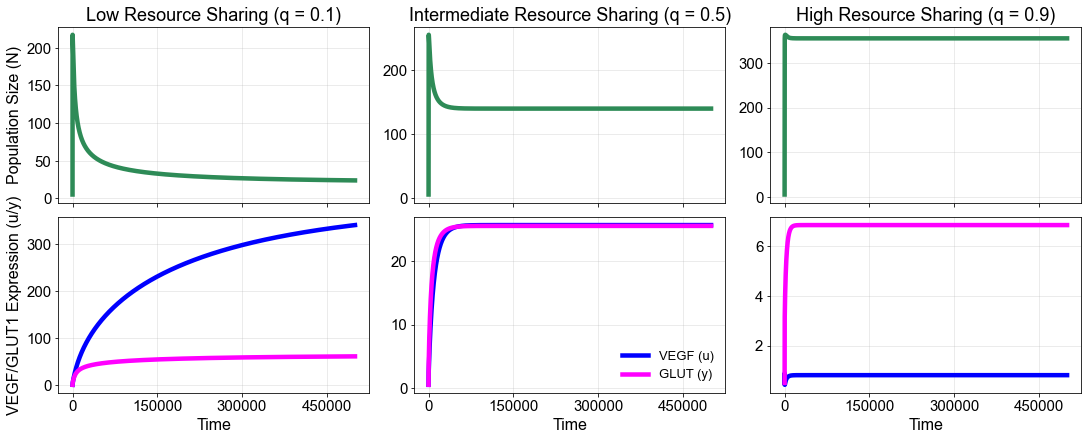

In [6]:

# ------------------------------ ESS Panel C ------------------------------
import matplotlib.ticker as ticker

q_cols = [0.1, 0.5, 0.9]
ess_by_q = runs_by_q(runs_ESS)

figC_ESS, axes = plt.subplots(2, 3, figsize=(15, 6), constrained_layout=True, sharex="col")

col_titles = {
    0.1: "Low Resource Sharing (q = 0.1)",
    0.5: "Intermediate Resource Sharing (q = 0.5)",
    0.9: "High Resource Sharing (q = 0.9)",
}

for j, q in enumerate(q_cols):
    run = ess_by_q[q]

    # Top row: N(t)
    axN = axes[0, j]
    axN.plot(run["t"], run["N"], color=N_COLOR, lw=4.5)
    axN.set_title(col_titles[q])
    if j == 0:
        axN.set_ylabel("Population Size (N)")
    axN.grid(True, alpha=0.3)

    # Bottom row: VEGF + GLUT overlay
    axUY = axes[1, j]
    axUY.plot(run["t"], run["u"], color=U_COLOR, lw=4.5, label="VEGF (u)")
    axUY.plot(run["t"], run["y"], color=Y_COLOR, lw=4.5, label="GLUT (y)")
    if j == 0:
        axUY.set_ylabel("VEGF/GLUT1 Expression (u/y)")
    axUY.set_xlabel("Time")
    axUY.grid(True, alpha=0.3)

    if j == 1:
        axUY.legend(frameon=False, loc="best")

# Use regular numeric notation on the x-axis and keep the ticks sparse enough
# to avoid overlap.
for ax in axes.flat:
    ax.xaxis.set_major_locator(ticker.MaxNLocator(nbins=5))
    ax.xaxis.set_major_formatter(ticker.StrMethodFormatter("{x:.0f}"))

figC_ESS_png = ESS_OUT / "Evolving_Neighborhood_Panel_C.png"
figC_ESS_svg = ESS_OUT / "Evolving_Neighborhood_Panel_C.svg"
figC_ESS.savefig(figC_ESS_png, dpi=300, bbox_inches="tight")
figC_ESS.savefig(figC_ESS_svg, format="svg", bbox_inches="tight", metadata={"Date": None})

print("Saved ESS Panel C figure:", figC_ESS_png)
plt.show()


Saved ESS Panel C TOTAL figure: C:\Users\80019048\Projects\vegf-glut1-coadaptation\outputs\evolving_neighborhoods\ESS_dynamics\short_time\Evolving_Neighborhood_Panel_C_TOTAL.png


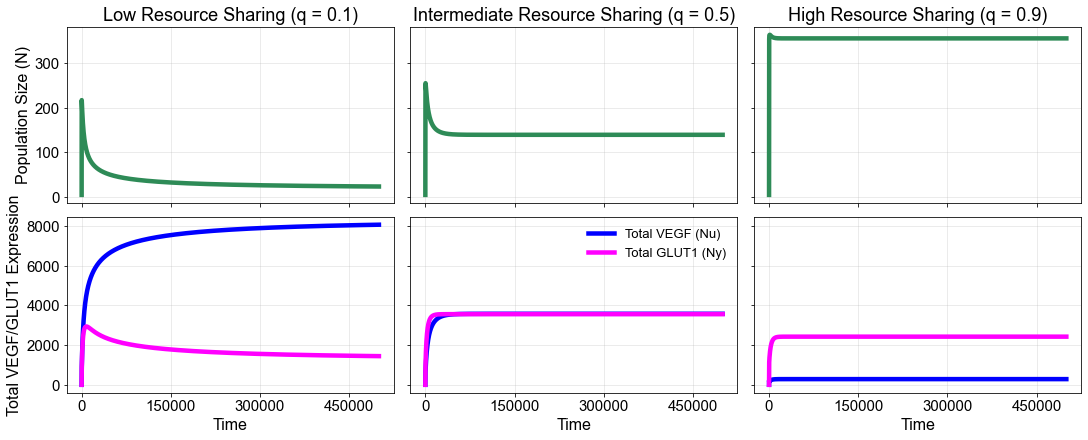

In [7]:
# ------------------------------ ESS Panel C (TOTAL) ------------------------------
import matplotlib.ticker as ticker

q_cols = [0.1, 0.5, 0.9]
ess_by_q = runs_by_q(runs_ESS)

figC_ESS, axes = plt.subplots(
    2, 3,
    figsize=(15, 6),
    constrained_layout=True,
    sharex="col",
    sharey="row"
)

col_titles = {
    0.1: "Low Resource Sharing (q = 0.1)",
    0.5: "Intermediate Resource Sharing (q = 0.5)",
    0.9: "High Resource Sharing (q = 0.9)",
}

for j, q in enumerate(q_cols):
    run = ess_by_q[q]

    total_u = run["N"] * run["u"]
    total_y = run["N"] * run["y"]

    # Top row: N(t)
    axN = axes[0, j]
    axN.plot(run["t"], run["N"], color=N_COLOR, lw=4.5)
    axN.set_title(col_titles[q])
    if j == 0:
        axN.set_ylabel("Population Size (N)")
    axN.grid(True, alpha=0.3)

    # Bottom row: total VEGF + total GLUT overlay
    axUY = axes[1, j]
    axUY.plot(run["t"], total_u, color=U_COLOR, lw=4.5, label="Total VEGF (Nu)")
    axUY.plot(run["t"], total_y, color=Y_COLOR, lw=4.5, label="Total GLUT1 (Ny)")
    if j == 0:
        axUY.set_ylabel("Total VEGF/GLUT1 Expression")
    axUY.set_xlabel("Time")
    axUY.grid(True, alpha=0.3)

    if j == 1:
        axUY.legend(frameon=False, loc="best")

# Use regular numeric notation on the x-axis and keep the ticks sparse enough
for ax in axes.flat:
    ax.xaxis.set_major_locator(ticker.MaxNLocator(nbins=5))
    ax.xaxis.set_major_formatter(ticker.StrMethodFormatter("{x:.0f}"))

figC_ESS_total_png = ESS_OUT / "Evolving_Neighborhood_Panel_C_TOTAL.png"
figC_ESS_total_svg = ESS_OUT / "Evolving_Neighborhood_Panel_C_TOTAL.svg"
figC_ESS.savefig(figC_ESS_total_png, dpi=300, bbox_inches="tight")
figC_ESS.savefig(figC_ESS_total_svg, format="svg", bbox_inches="tight", metadata={"Date": None})

print("Saved ESS Panel C TOTAL figure:", figC_ESS_total_png)
plt.show()